# Exercise: machine learning for segmentation

**Duration** ~40 min &nbsp;·&nbsp; **Session** Day 2, morning

A different field from the walkthrough, so your numbers will differ.

**Data**: `data/bbbc020/` field `15min_1`, and the Weka export in
`data/bbbc020/weka/`. If you exported your own from E4 yesterday, use those
instead — point `WEKA` at `results/weka/` and the rest will work unchanged.

In [1]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt

from skimage.measure import label
from skimage.color import label2rgb
from scipy.ndimage import distance_transform_edt
from skimage.segmentation import watershed

from course import DATA, show

FIELD = "15min_1"
WEKA = DATA / "bbbc020" / "weka"      # or: Path("../results/weka")

image = tifffile.imread(DATA / "bbbc020" / "images" / f"{FIELD}_cells.tif")
truth = tifffile.imread(DATA / "bbbc020" / "gt" / f"{FIELD}_cells_labels.tif")
print("annotated cells:", truth.max())

annotated cells: 26


## Task 1 — load the classifier output and find the cell class

Load `{FIELD}_cells_probability.tif` from the Weka folder. It has one map per
class. Work out **which index is the cell class**, without looking at the ground
truth.

<details>
<summary>Hint 1 — what shape is it?</summary>

`(2, height, width)` — the first axis is the class. Print `.shape` to confirm.
</details>

<details>
<summary>Hint 2 — how do I tell which is which?</summary>

Use something you already know about the image: stained cells are brighter than
background. For each class, threshold its probability at 0.5 and take the mean
of the *image* over those pixels.
</details>

In [2]:
# --- your turn ---
### BEGIN SOLUTION
probability = tifffile.imread(WEKA / f"{FIELD}_cells_probability.tif")
print("shape:", probability.shape)

for i in range(probability.shape[0]):
    predicted = probability[i] > 0.5
    print(f"class {i}: covers {predicted.mean():5.1%} of pixels, "
          f"mean image intensity there = {image[predicted].mean():5.1f}")
### END SOLUTION
### BEGIN PROMPT
# probability = ...   # TODO: load the probability map
# print("shape:", probability.shape)
#
# for i in range(probability.shape[0]):
#     predicted = ...   # TODO: this class's pixels
#     print(f"class {i}: covers {predicted.mean():5.1%} of pixels, "
#           f"mean image intensity there = {...:5.1f}")
### END PROMPT

shape: (2, 348, 512)
class 0: covers 45.2% of pixels, mean image intensity there =   7.0
class 1: covers 54.8% of pixels, mean image intensity there =  72.5


**Your answer:** which index is the cell class, and how do you know?
*(edit this cell)*

## Task 2 — semantic to instance

Build the cell mask, label it, and report how many objects you get. Then say why
that number is so far below the annotation.

<details>
<summary>Hint</summary>

`mask = probability[CELL] > 0.5`, then `label(mask).max()`.
</details>

In [3]:
CELL = 1   # set this from your answer to task 1

# --- your turn ---
### BEGIN SOLUTION
weka_mask = probability[CELL] > 0.5
weka_labels = label(weka_mask)

print("Weka objects:", weka_labels.max())
print("annotated   :", truth.max())
### END SOLUTION
### BEGIN PROMPT
# weka_mask = ...     # TODO: the cell-class mask
# weka_labels = ...   # TODO: label it
#
# print("Weka objects:", weka_labels.max())
# print("annotated   :", truth.max())
### END PROMPT

Weka objects: 33
annotated   : 26


**Your answer:** why does a pixel classifier under-count objects? Use the words
*semantic* and *instance*. *(edit this cell)*

## Task 3 — split them with a watershed

Apply the watershed to the Weka mask, seeding it from a thresholded distance
transform as in the walkthrough. Sweep the cut-off and pick a value.

<details>
<summary>Hint 1 — the three steps</summary>

```python
distance = distance_transform_edt(mask)
seeds = label(distance > t)
result = watershed(-distance, seeds, mask=mask)
```
</details>

<details>
<summary>Hint 2 — what cut-off?</summary>

Print `distance.max()` first. The cut-off is roughly the smallest object
"radius" you are prepared to accept, so it must be well below that maximum.
Try a range and watch the object count.
</details>

<details>
<summary>Hint 3 — why the minus sign?</summary>

`watershed` floods upward from low ground, so the landscape has to be inverted:
`-distance` turns each hilltop into a basin.
</details>

In [4]:
# --- your turn ---
### BEGIN SOLUTION
distance = distance_transform_edt(weka_mask)
print("largest distance-to-edge:", round(distance.max(), 1), "px")

for t in [5, 10, 15, 20, 25]:
    seeds = label(distance > t)
    print(f"distance > {t:2d} -> {seeds.max():2d} seeds -> "
          f"{watershed(-distance, seeds, mask=weka_mask).max():2d} objects")
### END SOLUTION
### BEGIN PROMPT
# distance = ...   # TODO: distance transform of the mask
# print("largest distance-to-edge:", round(distance.max(), 1), "px")
#
# for t in [5, 10, 15, 20, 25]:
#     seeds = ...        # TODO: label the cores above the cut-off
#     print(f"distance > {t:2d} -> {seeds.max():2d} seeds -> "
#           f"{...:2d} objects")   # TODO: watershed, then .max()
### END PROMPT

largest distance-to-edge: 55.9 px
distance >  5 -> 26 seeds -> 26 objects
distance > 10 -> 22 seeds -> 22 objects
distance > 15 -> 23 seeds -> 23 objects
distance > 20 -> 21 seeds -> 21 objects
distance > 25 -> 12 seeds -> 12 objects


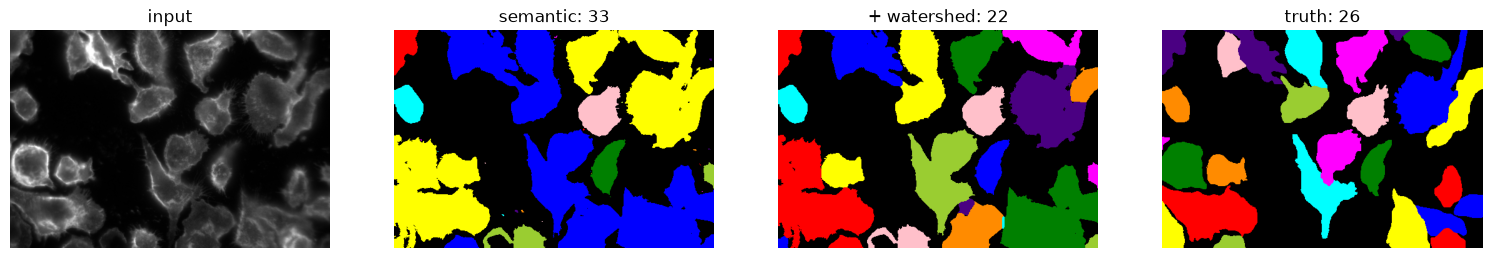

In [5]:
# --- your turn ---
### BEGIN SOLUTION
weka_instances = watershed(-distance, label(distance > 10), mask=weka_mask)

fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
show(image, title="input", ax=axes[0])
axes[1].imshow(label2rgb(weka_labels, bg_label=0)); axes[1].set_axis_off()
axes[1].set_title(f"semantic: {weka_labels.max()}")
axes[2].imshow(label2rgb(weka_instances, bg_label=0)); axes[2].set_axis_off()
axes[2].set_title(f"+ watershed: {weka_instances.max()}")
axes[3].imshow(label2rgb(truth, bg_label=0)); axes[3].set_axis_off()
axes[3].set_title(f"truth: {truth.max()}")
plt.show()
### END SOLUTION
### BEGIN PROMPT
# weka_instances = ...   # TODO: watershed with your chosen cut-off
#
# fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
# show(image, title="input", ax=axes[0])
# ... plot semantic, watershed and truth as label2rgb images ...
# plt.show()
### END PROMPT

## Task 4 — Cellpose, and the diameter

Run Cellpose on the same image with `diameter=None`, then try several fixed
diameters and see how much it matters.

<details>
<summary>Hint 1 — the call</summary>

```python
from cellpose import models
model = models.Cellpose(model_type="cyto", gpu=False)
masks, flows, styles, diam = model.eval(image, diameter=None, channels=[0, 0])
```
The first import takes a while — that is normal.
</details>

<details>
<summary>Hint 2 — what does diameter do?</summary>

It tells Cellpose how large it should expect objects to be, and it rescales the
image accordingly. Too small and cells shatter; too large and neighbours merge.
</details>

In [6]:
from cellpose import models

model = models.Cellpose(model_type="cyto", gpu=False)

# --- your turn ---
### BEGIN SOLUTION
masks, flows, styles, estimated = model.eval(image, diameter=None, channels=[0, 0])
print(f"estimated diameter: {estimated:.0f} px")
print(f"objects found     : {masks.max()}   (annotated: {truth.max()})")

for d in [20, 40, 80, 120]:
    m, _, _, _ = model.eval(image, diameter=d, channels=[0, 0])
    print(f"diameter = {d:3d}  ->  {m.max():3d} objects")
### END SOLUTION
### BEGIN PROMPT
# masks, flows, styles, estimated = ...   # TODO: eval with diameter=None
# print(f"estimated diameter: {estimated:.0f} px")
# print(f"objects found     : {masks.max()}   (annotated: {truth.max()})")
#
# for d in [20, 40, 80, 120]:
#     m, _, _, _ = ...    # TODO: eval with a fixed diameter
#     print(f"diameter = {d:3d}  ->  {m.max():3d} objects")
### END PROMPT

estimated diameter: 53 px
objects found     : 32   (annotated: 26)
diameter =  20  ->   34 objects
diameter =  40  ->   32 objects
diameter =  80  ->   27 objects
diameter = 120  ->   23 objects


**Your answer:** how sensitive is the result to `diameter`? If a Cellpose result
looked wrong, how would you check whether this was the cause?
*(edit this cell)*

## Task 5 — put the three side by side

Plot the input, your Weka+watershed result, and your Cellpose result, with the
annotation for reference. Then answer the question below.

<details>
<summary>Hint</summary>

Reuse the four-panel figure from task 3, swapping in the Cellpose masks.
</details>

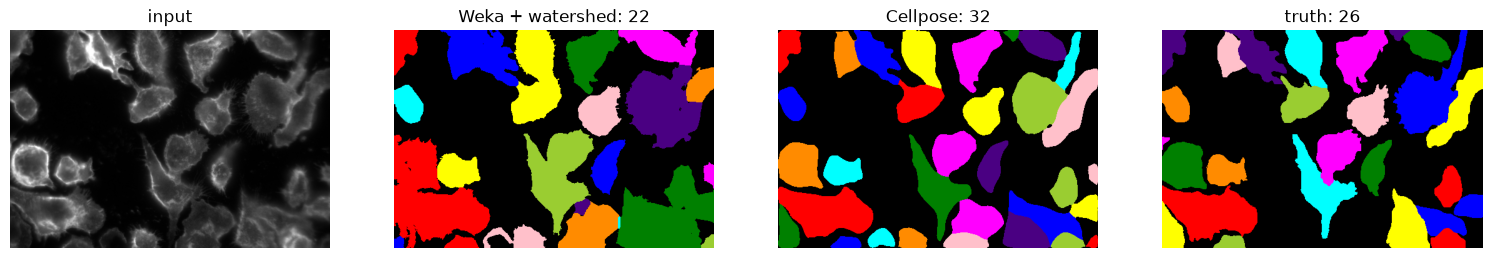

In [7]:
# --- your turn ---
### BEGIN SOLUTION
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
show(image, title="input", ax=axes[0])
for ax, (name, result) in zip(axes[1:], [
    ("Weka + watershed", weka_instances),
    ("Cellpose", masks),
    ("truth", truth),
]):
    ax.imshow(label2rgb(result, bg_label=0)); ax.set_axis_off()
    ax.set_title(f"{name}: {result.max()}")
plt.show()
### END SOLUTION
### BEGIN PROMPT
# ... plot input, Weka+watershed, Cellpose and truth side by side ...
### END PROMPT

**Your answer:** which result would you use, and — this is the harder half — how
would you *demonstrate* to someone else that you were right? Note that you cannot
yet, with only counts and pictures.
*(edit this cell)*

That gap is what the next notebook fills.

## If you finish early

Try the `nuclei` model on `{FIELD}_nuclei.tif` and compare it with a plain
threshold-and-watershed pipeline. Does the deep model earn its keep on the easy
channel?